# 06 — Macro factors from point-in-time market data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/06_macro_factors.ipynb)

No target other than the history: six monthly factor excess returns are built
at run time from public market series, and the sample itself is the target.
The question is whether each generator reproduces this factor history, tails included.

Runtime: about 3 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, CVineMarket, FleishmanMarket, load_factor_data

cvinemarketgen 0.2.0


## Load the factors

| Factor | Construction | Source |
|---|---|---|
| Equity DM | developed-market excess return, Mkt-RF | Fama-French |
| Equity EM | emerging minus developed excess return | Fama-French |
| Real premia | carry − 8 × change of the 10y TIPS real yield | FRED |
| Inflation | carry + 8 × change of the 10y breakeven | FRED |
| Credit | carry − 10 × change of the Baa − 10y spread | FRED |
| Commodity | DBC ETF total return minus the risk-free rate | Yahoo Finance |

The download is cached in `data/factors_cache.csv`.

In [2]:
factors = load_factor_data(start="2006-03", cache=os.path.join(ROOT, "data", "factors_cache.csv"))
factors.head()

factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07


,Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity
month,,,,,,
2006-04,0.0287,0.0434,-0.001242,0.015692,0.003408,0.066576
2006-05,-0.0412,-0.0619,-0.005208,-0.000967,0.002392,-0.008203
2006-06,-0.0059,-0.0085,-0.002733,-0.000200,0.000383,-0.012621
2006-07,-0.0025,0.0112,0.012517,-0.000225,0.000392,0.018134
2006-08,0.0223,0.0037,0.015608,-0.004250,-0.003600,-0.037456


## Look at the data before modelling it

In [3]:
pd.concat([factors.mean().mul(12).rename("mean (ann.)"), factors.std().mul(12 ** 0.5).rename("vol (ann.)"),
           factors.skew().rename("skew"), (factors.kurtosis() + 3).rename("kurt")], axis=1).round(3)

,mean (ann.),vol (ann.),skew,kurt
Equity DM,0.080,0.158,-0.641,4.735
Equity EM,-0.007,0.108,-0.024,2.987
Real premia,0.008,0.062,-0.633,5.405
Inflation,0.020,0.047,0.133,9.561
Credit,0.025,0.082,-1.910,17.585
Commodity,0.023,0.188,-0.531,4.963


In [4]:
factors.corr().round(2)

,Equity DM,Equity EM,Real premia,Inflation,Credit,Commodity
Equity DM,1.00,0.10,0.30,0.51,0.61,0.51
Equity EM,0.10,1.00,0.13,0.18,0.21,0.25
Real premia,0.30,0.13,1.00,0.21,-0.02,0.11
Inflation,0.51,0.18,0.21,1.00,0.56,0.58
Credit,0.61,0.21,-0.02,0.56,1.00,0.44
Commodity,0.51,0.25,0.11,0.58,0.44,1.00


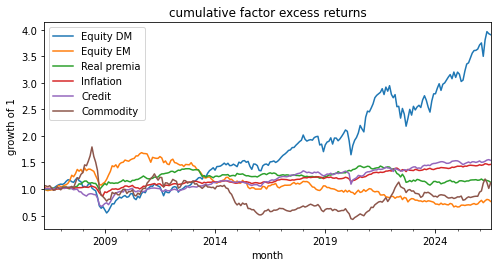

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
(1 + factors).cumprod().plot(ax=ax); ax.set_title("cumulative factor excess returns"); ax.set_ylabel("growth of 1"); plt.show()

## Targets are the sample

In [6]:
t = Targets.from_history(factors)
t.summary();

Targets for 6 assets (returns layer, history frequency M)
               mean     vol    skew     kurt
Equity DM    0.0066  0.0455 -0.6413   4.7346
Equity EM   -0.0006  0.0311 -0.0237   2.9870
Real premia  0.0007  0.0179 -0.6329   5.4048
Inflation    0.0017  0.0135  0.1327   9.5613
Credit       0.0021  0.0237 -1.9096  17.5847
Commodity    0.0020  0.0543 -0.5306   4.9626

correlation matrix:
             Equity DM  Equity EM  Real premia  Inflation  Credit  Commodity
Equity DM         1.00       0.10         0.30       0.51    0.61       0.51
Equity EM         0.10       1.00         0.13       0.18    0.21       0.25
Real premia       0.30       0.13         1.00       0.21   -0.02       0.11
Inflation         0.51       0.18         0.21       1.00    0.56       0.58
Credit            0.61       0.21        -0.02       0.56    1.00       0.44
Commodity         0.51       0.25         0.11       0.58    0.44       1.00

skewness and kurtosis: estimated from the history (244 observation

## C-vine generator, families from the history

In [7]:
t0 = time.time()
cv = CVineMarket(t, central="Equity DM", families="auto").fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.edges

fit: 142 s


,tree,edge,selected family,parameters
0,1,"Equity EM , Equity DM",gumbel 180°,theta=1.059
1,1,"Real premia , Equity DM",gumbel 180°,theta=1.209
2,1,"Inflation , Equity DM",gumbel 180°,theta=1.469
3,1,"Credit , Equity DM",gumbel 180°,theta=1.613
4,1,"Commodity , Equity DM",gumbel 180°,theta=1.441
5,2,"Real premia , Equity EM | Equity DM",clayton 180°,theta=0.158
6,2,"Inflation , Equity EM | Equity DM",clayton 180°,theta=0.185
7,2,"Credit , Equity EM | Equity DM",gumbel 0°,theta=1.136
8,2,"Commodity , Equity EM | Equity DM",gumbel 0°,theta=1.168
9,3,"Inflation , Real premia | Equity DM, Equity EM",gaussian 0°,theta=0.060


In [8]:
X = cv.simulate(25000, seed=1)
cv.diagnostics(X).summary();

25000 simulated observations (returns layer)
             mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
Equity DM         0.0066          0.0066       -0.0      0.0455         0.0455    0.0000      -0.6413         -0.6413    -0.0000       4.7346          4.7352     0.0006
Equity EM        -0.0006         -0.0006        0.0      0.0311         0.0309   -0.0002      -0.0237          0.0145     0.0382       2.9870          2.9929     0.0059
Real premia       0.0007          0.0007        0.0      0.0179         0.0179    0.0000      -0.6329         -0.6329    -0.0000       5.4048          5.4055     0.0007
Inflation         0.0017          0.0017        0.0      0.0135         0.0135    0.0000       0.1327          0.1327     0.0000       9.5613          9.5629     0.0016
Credit            0.0021          0.0021       -0.0      0.0237         0.0237    0.0000      -1.9096         

## Fleishman generator and the exceedance curves against the actual history

In [9]:
fm = FleishmanMarket(t).fit()
Xf = fm.simulate(25000, seed=1)
print(fm.diagnostics(Xf))

Diagnostics(n=25000, max |corr error|=0.0129, mean 1.3e-17, vol 1.1e-06, skew 1.1e-04, kurt 3.2e-03)


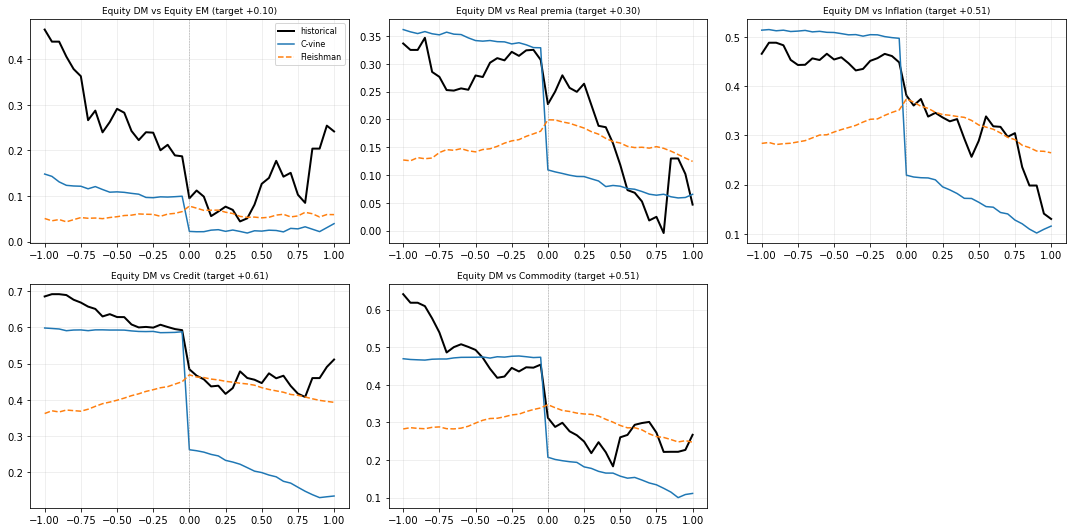

In [10]:
from cvinemarketgen import exceedance_curve
z = np.round(np.arange(-1, 1.001, 0.05), 3)
others = [a for a in t.assets if a != "Equity DM"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5)); axes = list(axes.flat)
for ax, a in zip(axes, others):
    for name, df, st in [("historical", factors, dict(color="black", lw=2)), ("C-vine", X, dict(color="tab:blue")), ("Fleishman", Xf, dict(color="tab:orange", ls="--"))]:
        ax.plot(z, exceedance_curve(df["Equity DM"], df[a], z).values, label=name, **st)
    ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_title(f"Equity DM vs {a} (target {t.corr.loc['Equity DM', a]:+.2f})", fontsize=9); ax.grid(alpha=0.25)
axes[-1].axis("off"); axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Reading the results

Every first-tree edge receives a Gumbel 180°: all five factors show lower-tail
dependence with Equity DM in this sample. The C-vine reproduces the jump at
zero on all five pairs; the Fleishman generator, with Gaussian dependence,
cannot. The 2008 episode makes the credit factor extremely heavy-tailed
(kurtosis above 17), which both marginal models accommodate.